# Focused SVD Experiment: query-adaptive alpha

This notebook keeps the current best SVD setup fixed and tests a minimal rule-based query-adaptive interpolation strategy.

Fixed setup:
- weighting: `similarity`
- graph expansion: `none` (`sim-only`)
- SVD rank: `512`
- document linking: `top-15`, `min_sim=0.45`
- query linking: `top-20`, `min_sim=0.45`

Adaptive component:
- choose a query-specific `alpha` based on simple query-link confidence statistics
- lower `alpha` = trust KG/SVD more
- higher `alpha` = trust dense retrieval more

The goal is to see whether reducing the worst query-level failures can improve over the fixed `alpha=0.30` setting.

In [1]:
import os
import re
import unicodedata
from pathlib import Path
from typing import Dict, List

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyterrier as pt
from scipy.sparse import csr_matrix
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

if not pt.java.started():
    pt.java.init()

def l2_normalize_rows(M: np.ndarray) -> np.ndarray:
    M = M.astype(np.float32, copy=False)
    denom = np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return (M / denom).astype(np.float32)

def ensure_run(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["qid"] = df["qid"].astype(str)
    df["docno"] = df["docno"].astype(str)
    if "score" not in df.columns:
        df["score"] = 0.0
    df["score"] = df["score"].astype(float)
    if "rank" not in df.columns:
        df = df.sort_values(["qid", "score"], ascending=[True, False])
        df["rank"] = df.groupby("qid").cumcount() + 1
    return df

_ws_re = re.compile(r"\s+")
_tags_re = re.compile(r"<[^>]+>")

def normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = _tags_re.sub(" ", s)
    s = unicodedata.normalize("NFKC", s)
    s = s.lower()
    s = re.sub(r"[^0-9a-zA-ZäöüßÄÖÜẞ]+", " ", s)
    s = _ws_re.sub(" ", s).strip()
    return s

def safe_concat(parts):
    clean = []
    for p in parts:
        if p is None:
            continue
        p = str(p)
        if p.strip() in ("", "N/A", "nan"):
            continue
        clean.append(p)
    return " ".join(clean)

def build_doc_text(row: pd.Series) -> str:
    return safe_concat([row.get("question"), row.get("choices_processed")])


/Users/user/miniconda3/envs/KG-re-ranking/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [2]:
PROJECT_ROOT = Path("/Users/user/Submissions/BEA-2026").resolve()
QB_PATH = PROJECT_ROOT / "qbank.csv"
QUERIES_PATH = PROJECT_ROOT / "queries.csv"
QRELS_PATH = PROJECT_ROOT / "qrels.tsv"

OUT_DIR = PROJECT_ROOT / "artifacts" / "svd_simonly_512_query_adaptive_alpha"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = PROJECT_ROOT / "artifacts" / "svd_ablation"
BGE_ART_DIR = PROJECT_ROOT / "artifacts" / "bge_gemma_reranker"

DENSE_MODEL = "deutsche-telekom/gbert-large-paraphrase-cosine"

K_CAND = 100
K_FINAL = 50
RANDOM_STATE = 42
SVD_DIM = 512
FIXED_ALPHA = 0.30

QUERY_STAT_COLS = ["mean", "max", "gap12", "gap15", "std"]
LOW_ALPHAS = [0.15, 0.20, 0.25]
HIGH_ALPHAS = [0.35, 0.40, 0.45]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)

qb = pd.read_csv(QB_PATH).fillna("N/A")
queries = pd.read_csv(QUERIES_PATH).fillna("")
qrels = pd.read_csv(QRELS_PATH, sep="\t").fillna(0)

qb["docno"] = qb["test_item_id"].astype(str)
qb["raw_text"] = qb.apply(build_doc_text, axis=1)
qb["text"] = qb["raw_text"].map(normalize_text)
corpus = qb[["docno", "text"]].copy()

topics = queries.rename(columns={"queries": "query"})[["qid", "query"]].copy()
topics["qid"] = topics["qid"].astype(str)
topics["query"] = topics["query"].astype(str).map(normalize_text)

qrels = qrels.rename(columns={"rel": "label"})[["qid", "docno", "label"]].copy()
qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)
qrels["label"] = qrels["label"].astype(int)


PROJECT_ROOT: /Users/user/Submissions/BEA-2026
OUT_DIR: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_query_adaptive_alpha


In [3]:
class FaissDenseRetriever(pt.Transformer):
    def __init__(self, corpus_df: pd.DataFrame, model_name: str, topk: int):
        super().__init__()
        self.topk = int(topk)
        cdf = corpus_df[["docno", "text"]].copy()
        cdf["docno"] = cdf["docno"].astype(str)
        cdf["text"] = cdf["text"].astype(str)
        self.docnos = cdf["docno"].tolist()
        self.st = SentenceTransformer(model_name, device="cpu")
        xdoc = self.st.encode(
            cdf["text"].tolist(),
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True,
        ).astype("float32")
        self.index = faiss.IndexFlatIP(xdoc.shape[1])
        self.index.add(xdoc)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        qids = topics_df["qid"].astype(str).tolist()
        qs = topics_df["query"].astype(str).tolist()
        q = self.st.encode(
            qs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype("float32")
        scores, idxs = self.index.search(q, self.topk)
        rows = []
        for i, qid in enumerate(qids):
            for rank, (j, sc) in enumerate(zip(idxs[i], scores[i]), start=1):
                if j < 0:
                    continue
                rows.append({"qid": qid, "docno": self.docnos[j], "score": float(sc), "rank": int(rank)})
        return pd.DataFrame(rows)

class StaticRunSource(pt.Transformer):
    def __init__(self, run_df: pd.DataFrame):
        super().__init__()
        self.run_df = ensure_run(run_df)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        return self.run_df.copy()

class KGRerankerAdaptive(pt.Transformer):
    def __init__(self, qid2vec: Dict[str, np.ndarray], docno2vec: Dict[str, np.ndarray], qid2alpha: Dict[str, float], default_alpha: float):
        super().__init__()
        self.qid2vec = qid2vec
        self.docno2vec = docno2vec
        self.qid2alpha = {str(k): float(v) for k, v in qid2alpha.items()}
        self.default_alpha = float(default_alpha)
        self.dim = int(next(iter(docno2vec.values())).shape[0])
        self.zero = np.zeros(self.dim, dtype=np.float32)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = ensure_run(df)
        out = df.copy()
        out["orig_score"] = out["score"].astype(float)
        Q = np.vstack([self.qid2vec.get(q, self.zero) for q in out["qid"]]).astype(np.float32)
        D = np.vstack([self.docno2vec.get(d, self.zero) for d in out["docno"]]).astype(np.float32)
        kg = (l2_normalize_rows(Q) * l2_normalize_rows(D)).sum(axis=1).astype(np.float32)
        alphas = out["qid"].astype(str).map(lambda q: self.qid2alpha.get(q, self.default_alpha)).astype(float).to_numpy()
        out["kg_score"] = kg.astype(float)
        out["alpha"] = alphas
        out["score"] = ((1.0 - alphas) * out["kg_score"].to_numpy() + alphas * out["orig_score"].to_numpy()).astype(float)
        out = out.sort_values(["qid", "score"], ascending=[True, False])
        out["rank"] = out.groupby("qid").cumcount() + 1
        return out

def cut_k(k: int) -> pt.Transformer:
    return pt.apply.generic(lambda df: df.groupby("qid", sort=False).head(int(k)))

def eval_at_k(pipelines, topics_df, qrels_df, k_eval: int) -> pd.DataFrame:
    metrics = [
        f"ndcg_cut.{k_eval}",
        "recip_rank",
        f"P.{k_eval}",
        f"recall.{k_eval}",
        f"map_cut.{k_eval}",
    ]
    df = pt.Experiment(
        [p for _, p in pipelines],
        topics_df,
        qrels_df,
        eval_metrics=metrics,
        names=[n for n, _ in pipelines],
        verbose=True,
        validate="ignore",
    )
    df = df.rename(columns={
        f"ndcg_cut.{k_eval}": f"nDCG@{k_eval}",
        "recip_rank": f"MRR@{k_eval}",
        f"P.{k_eval}": f"Prec@{k_eval}",
        f"recall.{k_eval}": f"Recall@{k_eval}",
        f"map_cut.{k_eval}": f"MAP@{k_eval}",
    }).copy()
    p = df[f"Prec@{k_eval}"].astype(float)
    r = df[f"Recall@{k_eval}"].astype(float)
    df[f"F1@{k_eval}"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
    cols = ["name", f"nDCG@{k_eval}", f"MRR@{k_eval}", f"Prec@{k_eval}", f"Recall@{k_eval}", f"F1@{k_eval}", f"MAP@{k_eval}"]
    return df[cols]

def filter_links(df: pd.DataFrame, id_col: str, min_sim: float, topk: int) -> pd.DataFrame:
    out = df.copy()
    out = out[out["w"].astype(float) >= float(min_sim)].copy()
    out = out.sort_values([id_col, "w"], ascending=[True, False])
    out = out.groupby(id_col, sort=False).head(int(topk)).reset_index(drop=True)
    return out

def build_svd_vectors(doc_df: pd.DataFrame, qid_df: pd.DataFrame, svd_dim: int):
    svd_skill_vocab = pd.Index(pd.concat([
        doc_df["skill_uri"].astype(str),
        qid_df["skill_uri"].astype(str),
    ])).unique().tolist()
    skill2idx = {u: i for i, u in enumerate(svd_skill_vocab)}
    n_sk = len(svd_skill_vocab)

    doc_ids = corpus["docno"].astype(str).unique().tolist()
    qid_ids = topics["qid"].astype(str).unique().tolist()
    doc2row = {d: i for i, d in enumerate(doc_ids)}
    qid2row = {q: i for i, q in enumerate(qid_ids)}

    def to_sparse(df, id_col, id2row):
        if df.empty:
            return csr_matrix((len(id2row), n_sk), dtype=np.float32)
        r = df[id_col].astype(str).map(id2row).to_numpy()
        c = df["skill_uri"].astype(str).map(skill2idx).to_numpy()
        v = df["w"].astype(float).to_numpy()
        return csr_matrix((v, (r, c)), shape=(len(id2row), n_sk), dtype=np.float32)

    X_doc = to_sparse(doc_df, "docno", doc2row)
    X_qid = to_sparse(qid_df, "qid", qid2row)
    max_dim = min(X_doc.shape[0] - 1, X_doc.shape[1] - 1)
    used_dim = max_dim if svd_dim >= max_dim else svd_dim
    svd = TruncatedSVD(n_components=used_dim, random_state=RANDOM_STATE)
    E_doc = normalize(svd.fit_transform(X_doc))
    E_qid = normalize(svd.transform(X_qid))
    explained = float(svd.explained_variance_ratio_.sum())
    docno2kg = {doc_ids[i]: E_doc[i].astype(np.float32) for i in range(len(doc_ids))}
    qid2kg = {qid_ids[i]: E_qid[i].astype(np.float32) for i in range(len(qid_ids))}
    return docno2kg, qid2kg, explained, used_dim

def to_table1_style(metrics_df: pd.DataFrame, ann_name: str, k_eval: int = 50) -> pd.DataFrame:
    df = metrics_df.copy()
    ann_ndcg = float(df.loc[df["name"] == ann_name, f"nDCG@{k_eval}"].iloc[0])
    df["Delta"] = df[f"nDCG@{k_eval}"].astype(float) - ann_ndcg
    df["Pct"] = np.where(ann_ndcg != 0, 100.0 * df["Delta"] / ann_ndcg, 0.0)
    out = pd.DataFrame({
        "Method": df["name"],
        "nDCG": df[f"nDCG@{k_eval}"].astype(float),
        "Delta": df["Delta"].astype(float),
        "%": df["Pct"].astype(float),
        "MRR": df[f"MRR@{k_eval}"].astype(float),
        "P": df[f"Prec@{k_eval}"].astype(float),
        "R": df[f"Recall@{k_eval}"].astype(float),
        "F1": df[f"F1@{k_eval}"].astype(float),
        "MAP": df[f"MAP@{k_eval}"].astype(float),
    })
    return out

dense_cache = CACHE_DIR / "dense100_run.csv"
if dense_cache.exists():
    dense_run = pd.read_csv(dense_cache)
    print("Loaded cached dense run:", dense_cache)
else:
    dense100 = FaissDenseRetriever(corpus, model_name=DENSE_MODEL, topk=K_CAND)
    dense_run = dense100.transform(topics)
    dense_run.to_csv(dense_cache, index=False)
    print("Saved dense run:", dense_cache)

dense_run = ensure_run(dense_run)
dense_source = StaticRunSource(dense_run)
cut50 = cut_k(K_FINAL)

doc_skills_df = pd.read_csv(CACHE_DIR / "doc_skills_df.csv")
qid_skills_df = pd.read_csv(CACHE_DIR / "qid_skills_df.csv")
doc_skills_df["w"] = doc_skills_df["w"].astype(float)
qid_skills_df["w"] = qid_skills_df["w"].astype(float)

doc_base = filter_links(doc_skills_df, "docno", min_sim=0.45, topk=15)
qid_base = filter_links(qid_skills_df, "qid", min_sim=0.45, topk=20)

docno2kg, qid2kg, explained, used_dim = build_svd_vectors(doc_base, qid_base, SVD_DIM)
print("used_dim:", used_dim)
print("explained_variance:", explained)

qid_stats = []
for qid, g in qid_base.groupby("qid", sort=False):
    w = sorted(g["w"].astype(float).tolist(), reverse=True)
    qid_stats.append({
        "qid": str(qid),
        "mean": float(np.mean(w)),
        "max": float(w[0]),
        "gap12": float(w[0] - w[1]) if len(w) > 1 else 0.0,
        "gap15": float(w[0] - w[4]) if len(w) > 4 else 0.0,
        "std": float(np.std(w, ddof=1)) if len(w) > 1 else 0.0,
    })
qid_stats_df = pd.DataFrame(qid_stats)

threshold_rows = []
for stat_col in QUERY_STAT_COLS:
    qs = qid_stats_df[stat_col].quantile([0.25, 0.50, 0.75]).tolist()
    for t in qs:
        threshold_rows.append({"stat": stat_col, "threshold": float(t)})
thresholds_df = pd.DataFrame(threshold_rows).drop_duplicates().reset_index(drop=True)
print(qid_stats_df.round(4).to_string(index=False))
print("\nThresholds:")
print(thresholds_df.to_string(index=False))

bge_ref = pd.read_csv(BGE_ART_DIR / "bge_gemma_reranker_table1_row.csv")
bge_ndcg = float(bge_ref["nDCG"].iloc[0])


Loaded cached dense run: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/dense100_run.csv


used_dim: 512
explained_variance: 0.7728558778762817
qid   mean    max  gap12  gap15    std
  0 0.7386 0.9050 0.0825 0.1579 0.0492
  1 0.7937 0.9314 0.0136 0.1042 0.0550
  2 0.8017 0.8993 0.0173 0.0552 0.0421
  3 0.7157 0.9152 0.0354 0.1824 0.0781
  4 0.6809 0.7984 0.0618 0.1010 0.0400
  5 0.6669 0.7784 0.0385 0.0987 0.0362
  6 0.8165 0.8997 0.0117 0.0618 0.0387
  7 0.7909 0.8504 0.0246 0.0357 0.0235
  8 0.6878 0.7417 0.0295 0.0487 0.0179
  9 0.6869 0.9109 0.1157 0.1912 0.0756
 10 0.5895 0.6760 0.0220 0.0741 0.0362
 11 0.6899 0.8428 0.0757 0.1195 0.0510
 12 0.7565 0.8142 0.0140 0.0420 0.0256
 13 0.7216 0.7557 0.0014 0.0179 0.0171
 14 0.6827 0.8062 0.0702 0.1083 0.0387

Thresholds:
 stat  threshold
 mean   0.684804
 mean   0.715715
 mean   0.773705
  max   0.788398
  max   0.842786
  max   0.902304
gap12   0.015662
gap12   0.029453
gap12   0.066022
gap15   0.051942
gap15   0.098714
gap15   0.113857
  std   0.030915
  std   0.038707
  std   0.050137


pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 71.83system/s]

pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 129.53system/s]

mean thr=0.6848 lo=0.15 hi=0.35 -> nDCG@50=0.647424


...

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 138.83system/s]

std thr=0.0501 lo=0.25 hi=0.40 -> nDCG@50=0.647644


pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 2/2 [00:00<00:00, 133.55system/s]

std thr=0.0501 lo=0.25 hi=0.45 -> nDCG@50=0.646681


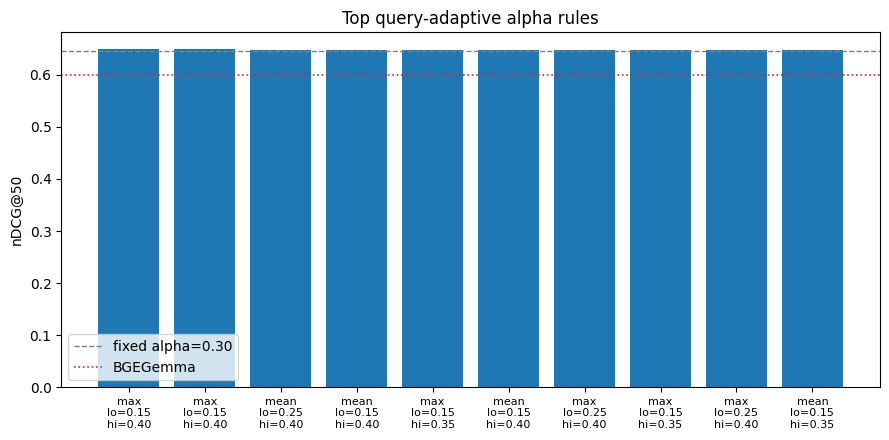

,rule,stat,threshold,alpha_low,alpha_high,high_conf_qids,low_conf_qids,nDCG,Delta,%,MRR,P,R,F1,MAP
0,binary_high_conf_low_alpha,max,0.8428,0.15,0.40,8,7,0.6494,0.1488,29.7317,0.9044,0.5640,0.4828,0.5202,0.4120
1,binary_high_conf_low_alpha,max,0.7884,0.15,0.40,11,4,0.6492,0.1486,29.6845,0.9044,0.5640,0.4828,0.5202,0.4113
2,binary_high_conf_low_alpha,mean,0.7737,0.25,0.40,4,11,0.6488,0.1482,29.6022,0.9044,0.5627,0.4821,0.5193,0.4110
3,binary_high_conf_low_alpha,mean,0.7157,0.15,0.40,8,7,0.6487,0.1481,29.5906,0.9042,0.5640,0.4828,0.5202,0.4109
4,binary_high_conf_low_alpha,max,0.8428,0.15,0.35,8,7,0.6487,0.1481,29.5878,0.9044,0.5640,0.4828,0.5202,0.4119
5,binary_high_conf_low_alpha,mean,0.7737,0.15,0.40,4,11,0.6486,0.1480,29.5744,0.9044,0.5627,0.4821,0.5193,0.4115
6,binary_high_conf_low_alpha,max,0.8428,0.25,0.40,8,7,0.6485,0.1479,29.5470,0.9044,0.5627,0.4819,0.5192,0.4110
7,binary_high_conf_low_alpha,max,0.7884,0.15,0.35,11,4,0.6485,0.1479,29.5453,0.9044,0.5640,0.4828,0.5202,0.4113
8,binary_high_conf_low_alpha,max,0.7884,0.25,0.40,11,4,0.6485,0.1479,29.5399,0.9044,0.5627,0.4819,0.5192,0.4108
9,binary_high_conf_low_alpha,mean,0.7157,0.15,0.35,8,7,0.6480,0.1474,29.4516,0.9042,0.5640,0.4828,0.5202,0.4110



Best row:

                                       Method     nDCG    Delta         %      MRR     P        R       F1      MAP                       rule stat  threshold  alpha_low  alpha_high  high_conf_qids  low_conf_qids  used_dim  explained_variance
adaptive(stat=max,thr=0.8428,lo=0.15,hi=0.40) 0.649432 0.148836 29.731727 0.904444 0.564 0.482795 0.520248 0.412036 binary_high_conf_low_alpha  max   0.842786       0.15         0.4               8              7       512            0.772856

Summary:

fixed_alpha=0.30
fixed_ndcg=0.646782
best_rule=binary_high_conf_low_alpha
best_stat=max
best_threshold=0.8427861928939819
best_alpha_low=0.15
best_alpha_high=0.4
best_high_conf_qids=8
best_low_conf_qids=7
best_ndcg=0.649432
improvement_vs_fixed=+0.002650
bgegemma_ndcg=0.600791
margin_vs_bgegemma=+0.048641
n_rules=135

Saved: /Users/user/Submissions/BEA-2026/artifacts/svd_simonly_512_query_adaptive_alpha/svd_simonly_512_query_adaptive_alpha_results.csv
Saved: /Users/user/Submissions/BEA-

In [4]:
rows = []
best_run = None
best_ndcg = -1.0
best_cfg = None

# fixed baseline row
fixed_name = f"dense@100>>KG(SVD sim-only @512,alpha={FIXED_ALPHA:.2f})->@50"
fixed_metrics = eval_at_k([
    ("ANN@100->@50", dense_source >> cut50),
    (fixed_name, dense_source >> KGRerankerAdaptive(qid2kg, docno2kg, {}, default_alpha=FIXED_ALPHA) >> cut50),
], topics, qrels, K_FINAL)
fixed_table = to_table1_style(fixed_metrics, ann_name="ANN@100->@50", k_eval=K_FINAL)
fixed_row = fixed_table[fixed_table["Method"] == fixed_name].iloc[0].to_dict()
fixed_row.update({
    "rule": "fixed",
    "stat": "fixed",
    "threshold": np.nan,
    "alpha_low": FIXED_ALPHA,
    "alpha_high": FIXED_ALPHA,
    "high_conf_qids": 15,
    "low_conf_qids": 0,
    "used_dim": int(used_dim),
    "explained_variance": float(explained),
})
rows.append(fixed_row)
best_ndcg = float(fixed_row["nDCG"])
best_cfg = dict(fixed_row)
best_run = (dense_source >> KGRerankerAdaptive(qid2kg, docno2kg, {}, default_alpha=FIXED_ALPHA) >> cut50).transform(topics)

for tr in thresholds_df.itertuples(index=False):
    stat_col = tr.stat
    threshold = float(tr.threshold)
    stat_map = dict(zip(qid_stats_df["qid"], qid_stats_df[stat_col]))
    for alpha_low in LOW_ALPHAS:
        for alpha_high in HIGH_ALPHAS:
            if alpha_low >= alpha_high:
                continue
            qid2alpha = {
                qid: (alpha_low if stat_map[qid] >= threshold else alpha_high)
                for qid in stat_map
            }
            high_conf_qids = sum(1 for a in qid2alpha.values() if np.isclose(a, alpha_low))
            low_conf_qids = sum(1 for a in qid2alpha.values() if np.isclose(a, alpha_high))
            name = f"adaptive(stat={stat_col},thr={threshold:.4f},lo={alpha_low:.2f},hi={alpha_high:.2f})"
            metrics_df = eval_at_k([
                ("ANN@100->@50", dense_source >> cut50),
                (name, dense_source >> KGRerankerAdaptive(qid2kg, docno2kg, qid2alpha, default_alpha=FIXED_ALPHA) >> cut50),
            ], topics, qrels, K_FINAL)
            table_df = to_table1_style(metrics_df, ann_name="ANN@100->@50", k_eval=K_FINAL)
            row = table_df[table_df["Method"] == name].iloc[0].to_dict()
            row.update({
                "rule": "binary_high_conf_low_alpha",
                "stat": stat_col,
                "threshold": threshold,
                "alpha_low": alpha_low,
                "alpha_high": alpha_high,
                "high_conf_qids": int(high_conf_qids),
                "low_conf_qids": int(low_conf_qids),
                "used_dim": int(used_dim),
                "explained_variance": float(explained),
            })
            rows.append(row)
            if float(row["nDCG"]) > best_ndcg:
                best_ndcg = float(row["nDCG"])
                best_cfg = dict(row)
                best_run = (dense_source >> KGRerankerAdaptive(qid2kg, docno2kg, qid2alpha, default_alpha=FIXED_ALPHA) >> cut50).transform(topics)
            print(f"{stat_col} thr={threshold:.4f} lo={alpha_low:.2f} hi={alpha_high:.2f} -> nDCG@50={float(row['nDCG']):.6f}")

results_df = pd.DataFrame(rows).sort_values(["nDCG", "stat", "threshold"], ascending=[False, True, True]).reset_index(drop=True)

results_path = OUT_DIR / "svd_simonly_512_query_adaptive_alpha_results.csv"
best_row_path = OUT_DIR / "svd_simonly_512_query_adaptive_alpha_best_row.csv"
best_run_path = OUT_DIR / "svd_simonly_512_query_adaptive_alpha_best_run.csv"
summary_path = OUT_DIR / "svd_simonly_512_query_adaptive_alpha_summary.txt"
plot_path = OUT_DIR / "svd_simonly_512_query_adaptive_alpha_top10.png"
stats_path = OUT_DIR / "svd_simonly_512_query_adaptive_alpha_query_stats.csv"

results_df.to_csv(results_path, index=False)
pd.DataFrame([best_cfg]).to_csv(best_row_path, index=False)
best_run.to_csv(best_run_path, index=False)
qid_stats_df.to_csv(stats_path, index=False)

summary_lines = [
    f"fixed_alpha={FIXED_ALPHA:.2f}",
    f"fixed_ndcg={float(fixed_row['nDCG']):.6f}",
    f"best_rule={best_cfg['rule']}",
    f"best_stat={best_cfg['stat']}",
    f"best_threshold={best_cfg['threshold']}",
    f"best_alpha_low={best_cfg['alpha_low']}",
    f"best_alpha_high={best_cfg['alpha_high']}",
    f"best_high_conf_qids={best_cfg['high_conf_qids']}",
    f"best_low_conf_qids={best_cfg['low_conf_qids']}",
    f"best_ndcg={float(best_cfg['nDCG']):.6f}",
    f"improvement_vs_fixed={float(best_cfg['nDCG']) - float(fixed_row['nDCG']):+.6f}",
    f"bgegemma_ndcg={bge_ndcg:.6f}",
    f"margin_vs_bgegemma={float(best_cfg['nDCG']) - bge_ndcg:+.6f}",
    f"n_rules={len(results_df) - 1}",
]
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

top10 = results_df.head(10).copy()
plt.figure(figsize=(9.0, 4.5))
plt.bar(range(len(top10)), top10['nDCG'])
plt.axhline(float(fixed_row['nDCG']), color='gray', linestyle='--', linewidth=1.0, label='fixed alpha=0.30')
plt.axhline(bge_ndcg, color='tab:red', linestyle=':', linewidth=1.2, label='BGEGemma')
plt.xticks(range(len(top10)), [f"{r['stat']}\nlo={r['alpha_low']:.2f}\nhi={r['alpha_high']:.2f}" if r['rule'] != 'fixed' else 'fixed\n0.30' for _, r in top10.iterrows()], fontsize=8)
plt.ylabel('nDCG@50')
plt.title('Top query-adaptive alpha rules')
plt.legend()
plt.tight_layout()
plt.savefig(plot_path, dpi=160)
plt.show()

display(results_df[["rule", "stat", "threshold", "alpha_low", "alpha_high", "high_conf_qids", "low_conf_qids", "nDCG", "Delta", "%", "MRR", "P", "R", "F1", "MAP"]].round(4).head(20))
print("\nBest row:\n")
print(pd.DataFrame([best_cfg]).to_string(index=False))
print("\nSummary:\n")
print("\n".join(summary_lines))
print("\nSaved:", results_path)
print("Saved:", best_row_path)
print("Saved:", best_run_path)
print("Saved:", summary_path)
print("Saved:", plot_path)
print("Saved:", stats_path)
